In [1]:
!pip install matplotlib seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


In [44]:
!pip uninstall mediapipe -y

# Cтабильная версию 0.10.9 (работает с новым API)
!pip install mediapipe==0.10.9

Found existing installation: mediapipe 0.10.32
Uninstalling mediapipe-0.10.32:
  Successfully uninstalled mediapipe-0.10.32
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.5/34.5 MB 28.2 MB/s  0:00:01 25.9 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 46.0 MB/s  0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 7.34.0
    Uninstalling protobuf-7.34.0:
      Successfully uninstalled protobuf-7.34.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [mediapipe]━ 1/2 [mediapipe]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
onnx 1.20.1 requires protobuf>=4.25.1, but you have protobuf 3.20.3 which is incompatible.


In [45]:
import os
import sys
import time
import json
import random
import warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from datetime import datetime
from scipy.interpolate import interp1d
from collections import deque
import cv2
import math

warnings.filterwarnings('ignore')
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True

print("Библиотеки импортированы")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

Библиотеки импортированы
PyTorch version: 2.10.0+cu128
CUDA available: True


In [46]:
class Config:
    """Конфигурация системы"""
    SKELETON_DIR = 'data/nturgbd/skeletons/nturgb+d_skeletons'
    MODELS_DIR = 'models'
    RESULTS_DIR = 'results'
    LOGS_DIR = 'runs'
    
    NUM_JOINTS = 25
    NUM_COORDS = 3
    MAX_PEOPLE = 4
    TARGET_FRAMES = 100
    
    BATCH_SIZE = 32
    NUM_WORKERS = 4
    EPOCHS = 100
    LEARNING_RATE = 0.001
    WEIGHT_DECAY = 0.01
    MIXED_PRECISION = True
    
    EARLY_STOPPING_PATIENCE = 20
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    EVALUATION_CLASSES = [
        'sitting down', 'standing up', 'walking', 'jumping',
        'fighting', 'dancing', 'shaking hands', 'hugging',
        'meeting', 'forming circle', 'tug of war'
    ]

config = Config()

for dir_path in [config.MODELS_DIR, config.RESULTS_DIR, config.LOGS_DIR]:
    os.makedirs(dir_path, exist_ok=True)

print(f"Конфигурация загружена. Устройство: {config.device}")

Конфигурация загружена. Устройство: cuda


Классы действий

In [47]:
INDIVIDUAL_ACTIONS = {
    'sitting': ['sitting down', 'sit', 'sitting'],
    'walking': ['walking', 'walk'],
    'jumping': ['jumping', 'jump', 'hop'],
    'smoking': ['smoking', 'smoke']
}

GROUP_ACTIONS = {
    'fight': ['fighting', 'punching', 'kicking', 'fighting 2'],
    'dance': ['dancing', 'dance'],
    'handshake': ['shaking hands', 'handshake', 'shake hands'],
    'hug': ['hugging', 'hug'],
    'meeting': ['meeting', 'gathering'],
    'circle': ['forming circle', 'circle', 'make circle'],
    'tug_of_war': ['tug of war', 'pulling', 'rope pulling']
}

REQUIRED_INDIVIDUAL = ['sitting', 'walking', 'jumping', 'smoking']
REQUIRED_GROUP = ['fight', 'dance', 'handshake', 'hug', 'meeting', 'circle', 'tug_of_war']

def map_ntu_to_required_actions(ntu_action_name):
    ntu_lower = ntu_action_name.lower()
    for req_action, ntu_list in INDIVIDUAL_ACTIONS.items():
        for ntu_name in ntu_list:
            if ntu_name in ntu_lower:
                return req_action, 'individual'
    for req_action, ntu_list in GROUP_ACTIONS.items():
        for ntu_name in ntu_list:
            if ntu_name in ntu_lower:
                return req_action, 'group'
    return None, None

def get_action_type(action_name):
    for req_action in REQUIRED_INDIVIDUAL:
        if req_action in action_name.lower():
            return 'individual'
    for req_action in REQUIRED_GROUP:
        if req_action in action_name.lower():
            return 'group'
    return 'unknown'

print("Классы действий настроены")
print(f"Индивидуальные: {REQUIRED_INDIVIDUAL}")
print(f"Групповые: {REQUIRED_GROUP}")

Классы действий настроены
Индивидуальные: ['sitting', 'walking', 'jumping', 'smoking']
Групповые: ['fight', 'dance', 'handshake', 'hug', 'meeting', 'circle', 'tug_of_war']


Обработка данных

In [48]:
def parse_skeleton(filepath, max_bodies=4, target_frames=100):
    try:
        with open(filepath, 'r') as f:
            lines = [l.strip() for l in f.readlines() if l.strip()]
        if len(lines) < 4:
            return None
        num_frames = int(lines[0])
        num_bodies = min(int(lines[1]), max_bodies)
        data = np.zeros((target_frames, max_bodies, 25, 3), dtype=np.float32)
        idx = 2
        actual_frames = min(num_frames, target_frames)
        for frame in range(actual_frames):
            for body in range(num_bodies):
                if idx >= len(lines):
                    break
                idx += 1
                try:
                    num_joints = int(lines[idx])
                    idx += 1
                except:
                    continue
                for j in range(min(num_joints, 25)):
                    if idx >= len(lines):
                        break
                    parts = lines[idx].split()
                    if len(parts) >= 3:
                        try:
                            x = float(parts[0])
                            y = float(parts[1])
                            z = float(parts[2])
                            if abs(x) < 100 and abs(y) < 100:
                                data[frame, body, j] = [x, y, z]
                        except:
                            pass
                    idx += 1
        return data
    except Exception as e:
        return None

def normalize_skeleton(data):
    if np.max(np.abs(data)) < 1e-6:
        return data
    T, M, V, C = data.shape
    normalized = np.zeros_like(data)
    for m in range(M):
        hip = data[:, m, 0, :].copy()
        person_data = data[:, m, :, :] - hip[:, np.newaxis, :]
        scale = np.max(np.abs(person_data))
        if scale > 1e-6:
            person_data = person_data / scale
        normalized[:, m, :, :] = person_data
    return normalized

def interpolate_frames(data, target=100):
    T, M, V, C = data.shape
    if T == target:
        return data
    old_t = np.linspace(0, 1, T)
    new_t = np.linspace(0, 1, target)
    result = np.zeros((target, M, V, C), dtype=np.float32)
    for m in range(M):
        for v in range(V):
            for c in range(C):
                f = interp1d(old_t, data[:, m, v, c], kind='linear',
                            bounds_error=False,
                            fill_value=(data[0, m, v, c], data[-1, m, v, c]))
                result[:, m, v, c] = f(new_t)
    return result

def extract_label(filename):
    parts = filename.replace('.skeleton', '').split('A')
    if len(parts) >= 2:
        return int(parts[-1]) - 1
    return 0

print("Функции обработки данных загружены")

Функции обработки данных загружены


Dataset класс

In [49]:
class SkeletonDataset(Dataset):
    def __init__(self, files, skeleton_dir, max_people=4, target_frames=100, augment=False):
        self.files = files
        self.skeleton_dir = skeleton_dir
        self.max_people = max_people
        self.target_frames = target_frames
        self.augment = augment
    
    def __len__(self):
        return len(self.files)
    
    def __getitem__(self, idx):
        filepath = os.path.join(self.skeleton_dir, self.files[idx])
        data = parse_skeleton(filepath, max_bodies=self.max_people, target_frames=self.target_frames)
        if data is None:
            data = np.zeros((self.target_frames, self.max_people, 25, 3), dtype=np.float32)
            label = 0
        else:
            data = normalize_skeleton(data)
            label = extract_label(self.files[idx])
        if self.augment and np.max(np.abs(data)) > 1e-6:
            data = self.augment_skeleton(data)
        tensor = torch.FloatTensor(data).permute(3, 0, 2, 1)
        return tensor, label
    
    def augment_skeleton(self, data):
        if random.random() > 0.5:
            noise = np.random.normal(0, 0.02, data.shape).astype(np.float32)
            data = data + noise
        if random.random() > 0.7:
            mask = np.random.random(data.shape).astype(np.float32) > 0.1
            data = data * mask
        if random.random() > 0.5:
            scale = random.uniform(0.9, 1.1)
            data = data * scale
        if random.random() > 0.5:
            shift = random.randint(-5, 5)
            data = np.roll(data, shift, axis=0)
        return data

print("Dataset класс создан")

Dataset класс создан


Модель MLP

In [50]:
class SimpleMLP(nn.Module):
    def __init__(self, num_classes=60):
        super().__init__()
        self.num_classes = num_classes
        input_dim = 3 * 25 * 100 * 4
        self.net = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        N = x.shape[0]
        x = x.reshape(N, -1)
        return self.net(x)

print("MLP модель создана")

MLP модель создана


Модель 3D CNN

In [51]:
class Enhanced3DCNN(nn.Module):
    def __init__(self, num_classes=60, num_people=4):
        super().__init__()
        self.num_people = num_people
        self.conv1 = nn.Sequential(
            nn.Conv3d(3, 64, kernel_size=(3, 1, 1), padding=(1, 0, 0)),
            nn.BatchNorm3d(64),
            nn.ReLU(inplace=True),
            nn.Conv3d(64, 64, kernel_size=(3, 1, 1), padding=(1, 0, 0)),
            nn.BatchNorm3d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(kernel_size=(2, 1, 1), stride=(2, 1, 1))
        )
        self.conv2 = nn.Sequential(
            nn.Conv3d(64, 128, kernel_size=(3, 1, 1), padding=(1, 0, 0)),
            nn.BatchNorm3d(128),
            nn.ReLU(inplace=True),
            nn.Conv3d(128, 128, kernel_size=(3, 1, 1), padding=(1, 0, 0)),
            nn.BatchNorm3d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(kernel_size=(2, 1, 1), stride=(2, 1, 1))
        )
        self.conv3 = nn.Sequential(
            nn.Conv3d(128, 256, kernel_size=(3, 1, 1), padding=(1, 0, 0)),
            nn.BatchNorm3d(256),
            nn.ReLU(inplace=True),
            nn.Conv3d(256, 256, kernel_size=(3, 1, 1), padding=(1, 0, 0)),
            nn.BatchNorm3d(256),
            nn.ReLU(inplace=True)
        )
        self.conv4 = nn.Sequential(
            nn.Conv3d(256, 512, kernel_size=(3, 1, 1), padding=(1, 0, 0)),
            nn.BatchNorm3d(512),
            nn.ReLU(inplace=True)
        )
        self.fusion = nn.Sequential(
            nn.Linear(512 * num_people, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(1024, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
    
    def forward(self, x):
        N, C, T, V, M = x.shape
        x = x.permute(0, 4, 1, 2, 3).reshape(N * M, C, T, V)
        x = x.unsqueeze(-1)
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = F.adaptive_avg_pool3d(x, (1, 1, 1))
        x = x.view(N, M, -1)
        x = x.reshape(N, -1)
        return self.fusion(x)

print("3D CNN модель создана")

3D CNN модель создана


Модель ST-GCN

In [52]:
class GraphConvolution(nn.Module):
    def __init__(self, in_channels, out_channels, num_joints=25):
        super().__init__()
        self.adj = nn.Parameter(torch.ones(num_joints, num_joints) / num_joints)
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
    
    def forward(self, x):
        N, C, T, V = x.shape
        x = x.permute(0, 2, 3, 1).contiguous()
        x = x.view(N * T, V, C)
        adj_norm = F.softmax(self.adj, dim=1)
        x = torch.matmul(adj_norm, x)
        x = x.view(N, T, V, C).permute(0, 3, 1, 2).contiguous()
        x = self.conv(x)
        x = self.bn(x)
        return self.relu(x)

class TemporalConvolution(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=9, stride=1):
        super().__init__()
        padding = (kernel_size - 1) // 2
        self.conv = nn.Conv2d(in_channels, out_channels,
                             kernel_size=(kernel_size, 1),
                             padding=(padding, 0), stride=(stride, 1))
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
    
    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        return self.relu(x)

class STGCNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, num_joints=25, stride=1):
        super().__init__()
        self.gcn = GraphConvolution(in_channels, out_channels, num_joints)
        self.tcn = TemporalConvolution(out_channels, out_channels, kernel_size=9, stride=stride)
        self.residual = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.residual = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=(stride, 1)),
                nn.BatchNorm2d(out_channels)
            )
    
    def forward(self, x):
        res = self.residual(x)
        x = self.gcn(x)
        x = self.tcn(x)
        return F.relu(x + res)

class STGCN(nn.Module):
    def __init__(self, num_classes=60, num_joints=25, num_people=4, in_channels=3):
        super().__init__()
        self.num_people = num_people
        self.conv_init = nn.Conv2d(in_channels, 64, kernel_size=1)
        self.bn_init = nn.BatchNorm2d(64)
        self.stgcn_blocks = nn.ModuleList([
            STGCNBlock(64, 64, num_joints, stride=1),
            STGCNBlock(64, 64, num_joints, stride=1),
            STGCNBlock(64, 64, num_joints, stride=1),
            STGCNBlock(64, 128, num_joints, stride=2),
            STGCNBlock(128, 128, num_joints, stride=1),
            STGCNBlock(128, 128, num_joints, stride=1),
            STGCNBlock(128, 256, num_joints, stride=2),
            STGCNBlock(256, 256, num_joints, stride=1),
            STGCNBlock(256, 256, num_joints, stride=1)
        ])
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fusion = nn.Sequential(
            nn.Linear(256 * num_people, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(1024, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
    
    def forward(self, x):
        N, C, T, V, M = x.shape
        all_features = []
        for m in range(M):
            person_x = x[:, :, :, :, m]
            person_x = self.conv_init(person_x)
            person_x = self.bn_init(person_x)
            person_x = F.relu(person_x)
            for block in self.stgcn_blocks:
                person_x = block(person_x)
            person_x = self.global_pool(person_x)
            person_x = person_x.view(N, -1)
            all_features.append(person_x)
        x = torch.cat(all_features, dim=1)
        return self.fusion(x)

print("ST-GCN модель создана")

ST-GCN модель создана


Модель Transformer

In [53]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0).transpose(0, 1)
        self.register_buffer('pe', pe)
    
    def forward(self, x):
        return x + self.pe[:x.size(0), :]

class SkeletonTransformer(nn.Module):
    def __init__(self, num_classes=60, num_joints=25, num_people=4,
                 d_model=512, nhead=8, num_layers=6, dim_feedforward=2048, dropout=0.1):
        super().__init__()
        self.num_people = num_people
        self.d_model = d_model
        input_dim = 3 * num_joints
        self.input_proj = nn.Linear(input_dim, d_model)
        self.pos_encoder = PositionalEncoding(d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
            dropout=dropout, activation='gelu', batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model))
        self.person_classifiers = nn.ModuleList([
            nn.Sequential(
                nn.Linear(d_model, 512),
                nn.ReLU(inplace=True),
                nn.Dropout(dropout),
                nn.Linear(512, 256),
                nn.ReLU(inplace=True),
                nn.Dropout(dropout),
                nn.Linear(256, num_classes)
            ) for _ in range(num_people)
        ])
        self.fusion = nn.Linear(num_classes * num_people, num_classes)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        N, C, T, V, M = x.shape
        x = x.permute(0, 2, 4, 1, 3).contiguous()
        x = x.view(N, T, M, -1)
        all_predictions = []
        for m in range(M):
            person_x = x[:, :, m, :]
            person_x = self.input_proj(person_x)
            cls_tokens = self.cls_token.expand(N, -1, -1)
            person_x = torch.cat([cls_tokens, person_x], dim=1)
            person_x = self.pos_encoder(person_x)
            person_x = self.transformer(person_x)
            cls_output = person_x[:, 0, :]
            cls_output = self.dropout(cls_output)
            pred = self.person_classifiers[m](cls_output)
            all_predictions.append(pred)
        combined = torch.cat(all_predictions, dim=1)
        return self.fusion(combined)

print("Transformer модель создана")

Transformer модель создана


Словарь моделей

In [54]:
MODELS = {
    'mlp': {
        'class': SimpleMLP,
        'description': 'Простая полносвязная сеть (MLP) - быстрый baseline',
        'params': {'num_classes': 60},
        'features': ['простая', 'быстрая', 'низкая точность']
    },
    '3dcnn': {
        'class': Enhanced3DCNN,
        'description': '3D сверточная сеть - учитывает пространственно-временную структуру',
        'params': {'num_classes': 60, 'num_people': Config.MAX_PEOPLE},
        'features': ['пространственно-временные признаки', 'средняя скорость', 'хорошая точность']
    },
    'stgcn': {
        'class': STGCN,
        'description': 'Пространственно-временная графовая сеть (ST-GCN)',
        'params': {'num_classes': 60, 'num_joints': 25, 'num_people': Config.MAX_PEOPLE, 'in_channels': 3},
        'features': ['графовая структура', 'эффективность', 'высокая точность']
    },
    'transformer': {
        'class': SkeletonTransformer,
        'description': 'Трансформер для скелетных последовательностей',
        'params': {'num_classes': 60, 'num_joints': 25, 'num_people': Config.MAX_PEOPLE,
                   'd_model': 256, 'nhead': 8, 'num_layers': 4, 'dim_feedforward': 512},
        'features': ['долгосрочные зависимости', 'гибкость', 'высокая точность']
    }
}

print("Словарь моделей настроен")
for name, info in MODELS.items():
    print(f"  {name}: {info['description']}")

Словарь моделей настроен
  mlp: Простая полносвязная сеть (MLP) - быстрый baseline
  3dcnn: 3D сверточная сеть - учитывает пространственно-временную структуру
  stgcn: Пространственно-временная графовая сеть (ST-GCN)
  transformer: Трансформер для скелетных последовательностей


Функция обучения

In [55]:
def train_model(model_name='3dcnn', num_epochs=None):
    config = Config()
    skeleton_dir = config.SKELETON_DIR
    
    if not os.path.exists(skeleton_dir):
        raise FileNotFoundError(f"Не найдена директория: {skeleton_dir}")
    if num_epochs is None:
        num_epochs = config.EPOCHS
    
    print(f"Обучение модели: {model_name.upper()}")
    
    all_files = [f for f in os.listdir(skeleton_dir) if f.endswith('.skeleton')]
    all_labels = [extract_label(f) for f in all_files]
    num_classes = max(all_labels) + 1
    
    os.makedirs(config.MODELS_DIR, exist_ok=True)
    os.makedirs(config.LOGS_DIR, exist_ok=True)
    
    train_files, val_files = train_test_split(all_files, test_size=0.1, random_state=42)
    
    train_dataset = SkeletonDataset(train_files, skeleton_dir, max_people=config.MAX_PEOPLE,
                                    target_frames=config.TARGET_FRAMES, augment=True)
    val_dataset = SkeletonDataset(val_files, skeleton_dir, max_people=config.MAX_PEOPLE,
                                  target_frames=config.TARGET_FRAMES, augment=False)
    
    train_loader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE, shuffle=True,
                              num_workers=config.NUM_WORKERS, pin_memory=True, drop_last=True)
    val_loader = DataLoader(val_dataset, batch_size=config.BATCH_SIZE, shuffle=False,
                            num_workers=config.NUM_WORKERS, pin_memory=True)
    
    model_params = MODELS[model_name]['params'].copy()
    model = MODELS[model_name]['class'](**model_params).to(config.device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=config.LEARNING_RATE, weight_decay=config.WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=10)
    scaler = torch.amp.GradScaler('cuda') if config.MIXED_PRECISION else None
    
    run_name = f"{model_name}_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
    writer = SummaryWriter(log_dir=os.path.join(config.LOGS_DIR, run_name))
    
    print(f"Параметры модели: {sum(p.numel() for p in model.parameters()):,}")
    print(f"Устройство: {config.device}")
    
    best_acc = 0
    patience = 0
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    
    for epoch in range(num_epochs):
        epoch_start = time.time()
        
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        
        for data, labels in train_loader:
            data, labels = data.to(config.device), labels.to(config.device)
            optimizer.zero_grad()
            
            if config.MIXED_PRECISION and scaler is not None:
                with torch.amp.autocast('cuda'):
                    outputs = model(data)
                    loss = criterion(outputs, labels)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                outputs = model(data)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
            
            train_loss += loss.item()
            _, predicted = outputs.max(1)
            train_correct += predicted.eq(labels).sum().item()
            train_total += labels.size(0)
        
        train_acc = 100. * train_correct / train_total
        
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for data, labels in val_loader:
                data, labels = data.to(config.device), labels.to(config.device)
                if config.MIXED_PRECISION:
                    with torch.amp.autocast('cuda'):
                        outputs = model(data)
                else:
                    outputs = model(data)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = outputs.max(1)
                val_correct += predicted.eq(labels).sum().item()
                val_total += labels.size(0)
        
        val_acc = 100. * val_correct / val_total
        scheduler.step(val_acc)
        
        history['train_loss'].append(train_loss / len(train_loader))
        history['val_loss'].append(val_loss / len(val_loader))
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        
        epoch_time = time.time() - epoch_start
        
        if val_acc > best_acc:
            best_acc = val_acc
            patience = 0
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'accuracy': val_acc,
                'num_classes': num_classes,
                'model_name': model_name,
                'history': history
            }, os.path.join(config.MODELS_DIR, f'{model_name}_best.pth'))
        else:
            patience += 1
        
        writer.add_scalar('Loss/train', train_loss/len(train_loader), epoch)
        writer.add_scalar('Loss/val', val_loss/len(val_loader), epoch)
        writer.add_scalar('Accuracy/train', train_acc, epoch)
        writer.add_scalar('Accuracy/val', val_acc, epoch)
        
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:03d}/{num_epochs} | Loss={train_loss/len(train_loader):.4f} | "
                  f"Train Acc={train_acc:.2f}% | Val Acc={val_acc:.2f}% | Time={epoch_time:.1f}s")
        
        if patience >= config.EARLY_STOPPING_PATIENCE:
            print(f"Ранняя остановка на эпохе {epoch+1}")
            break
    
    writer.close()
    print(f"Обучение завершено! Лучшая точность: {best_acc:.2f}%")
    print(f"Модель сохранена: {config.MODELS_DIR}/{model_name}_best.pth")
    
    plot_training_history(history, model_name, 
                     os.path.join(config.RESULTS_DIR, f'{model_name}_training.png'))
    
    return model, history, best_acc

print("Функция обучения создана")

Функция обучения создана


Функция оценки

In [56]:
def evaluate_model(model_path, test_files=None):
    config = Config()
    skeleton_dir = config.SKELETON_DIR
    
    print(f"Оценка модели")
    
    checkpoint = torch.load(model_path, map_location=config.device, weights_only=False)
    model_name = checkpoint.get('model_name', 'unknown')
    num_classes = checkpoint.get('num_classes', 60)
    
    model = MODELS[model_name]['class'](**MODELS[model_name]['params'].copy()).to(config.device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    
    print(f"Модель: {model_name}")
    print(f"Лучшая точность при обучении: {checkpoint.get('accuracy', 0):.2f}%")
    
    if test_files is None:
        all_files = [f for f in os.listdir(skeleton_dir) if f.endswith('.skeleton')]
        _, test_files = train_test_split(all_files, test_size=0.1, random_state=42)
    
    test_dataset = SkeletonDataset(test_files, skeleton_dir, max_people=config.MAX_PEOPLE,
                                   target_frames=config.TARGET_FRAMES, augment=False)
    test_loader = DataLoader(test_dataset, batch_size=config.BATCH_SIZE, shuffle=False,
                             num_workers=config.NUM_WORKERS, pin_memory=True)
    
    all_preds = []
    all_labels = []
    inference_times = []
    
    with torch.no_grad():
        for data, labels in test_loader:
            data = data.to(config.device)
            start_time = time.time()
            outputs = model(data)
            inference_times.append(time.time() - start_time)
            _, predicted = outputs.max(1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
    
    accuracy = accuracy_score(all_labels, all_preds) * 100
    precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0) * 100
    recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0) * 100
    f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0) * 100
    
    avg_inference_time = np.mean(inference_times)
    fps = 1.0 / avg_inference_time if avg_inference_time > 0 else 0
    
    print(f"Метрики на тестовой выборке:")
    print(f"   Accuracy:  {accuracy:.2f}%")
    print(f"   Precision: {precision:.2f}%")
    print(f"   Recall:    {recall:.2f}%")
    print(f"   F1-score:  {f1:.2f}%")
    print(f"   FPS:       {fps:.2f}")

    plot_confusion_matrix(all_labels, all_preds,
                     save_path=os.path.join(config.RESULTS_DIR, f'{model_name}_cm.png'))
    
    return {
        'model_name': model_name,
        'description': MODELS[model_name]['description'],
        'features': MODELS[model_name]['features'],
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'fps': fps,
        'predictions': all_preds,
        'labels': all_labels
    }

print("Функция оценки создана")

Функция оценки создана


Сравнение моделей

In [57]:
def compare_all_models():
    config = Config()
    
    print(f"Сравнение всех моделей")
    
    results = {}
    model_list = ['mlp', '3dcnn', 'stgcn', 'transformer']
    
    for model_name in model_list:
        model_path = os.path.join(config.MODELS_DIR, f'{model_name}_best.pth')
        if not os.path.exists(model_path):
            print(f"Модель {model_name} не найдена. Пропускаем.")
            continue
        
        print(f"Оценка модели: {model_name.upper()}")
        eval_result = evaluate_model(model_path)
        results[model_name] = eval_result
    
    if len(results) >= 1:
        print(f"Сводное сравнение всех моделей")
        
        comparison_data = {}
        for model_name, res in results.items():
            comparison_data[model_name.upper()] = {
                'Accuracy (%)': res['accuracy'],
                'Precision (%)': res['precision'],
                'Recall (%)': res['recall'],
                'F1-score (%)': res['f1_score'],
                'FPS': res['fps']
            }
        
        comparison = pd.DataFrame(comparison_data).T
        print(comparison.round(2))
        
        if results:
            best_model = max(results.keys(), key=lambda x: results[x]['accuracy'])
            print(f"Лучшая модель по точности: {best_model.upper()}")
            print(f"   Accuracy: {results[best_model]['accuracy']:.2f}%")
            
            fastest_model = max(results.keys(), key=lambda x: results[x]['fps'])
            print(f"Самая быстрая модель: {fastest_model.upper()}")
            print(f"   FPS: {results[fastest_model]['fps']:.2f}")
        
        comparison.to_csv(os.path.join(config.RESULTS_DIR, 'models_comparison.csv'))
        print(f"Сравнение сохранено: {config.RESULTS_DIR}/models_comparison.csv")
        plot_model_comparison(results,
                     save_path=os.path.join(config.RESULTS_DIR, 'models_comparison.png'))
    
    return results

print("Функция сравнения создана")

Функция сравнения создана


MediaPipe детектор

In [58]:
class MediaPipeDetector:
    """Детектор скелетов - работает с MediaPipe 0.8.x и 0.10.x"""
    
    def __init__(self, max_people=4):
        self.max_people = max_people
        
        try:
            import mediapipe as mp
            print(f"MediaPipe версия: {mp.__version__}")
            
            # Пробуем старый API (0.8.x - 0.9.x)
            if hasattr(mp, 'solutions'):
                print("Используется старый API MediaPipe")
                self.mp_pose = mp.solutions.pose
                self.pose = self.mp_pose.Pose(
                    static_image_mode=False,
                    model_complexity=1,
                    min_detection_confidence=0.5,
                    min_tracking_confidence=0.5
                )
                self.mp_drawing = mp.solutions.drawing_utils
                self.use_old_api = True
            else:
                # Новый API (0.10.0+)
                print("Используется новый API MediaPipe")
                from mediapipe.tasks import python
                from mediapipe.tasks.python import vision
                
                # Создаём временный файл модели если нужно
                import urllib.request
                model_path = 'pose_landmarker_full.task'
                if not os.path.exists(model_path):
                    url = 'https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_full/float16/1/pose_landmarker_full.task'
                    urllib.request.urlretrieve(url, model_path)
                
                base_options = python.BaseOptions(model_asset_path=model_path)
                options = vision.PoseLandmarkerOptions(
                    base_options=base_options,
                    running_mode=vision.RunningMode.VIDEO,
                    num_poses=max_people,
                    min_pose_detection_confidence=0.5,
                    min_pose_presence_confidence=0.5
                )
                self.pose = vision.PoseLandmarker.create_from_options(options)
                self.mp_drawing = mp.solutions.drawing_utils
                self.use_old_api = False
                
        except Exception as e:
            print(f"Ошибка инициализации MediaPipe: {e}")
            self.pose = None
            self.mp_drawing = None
            self.use_old_api = False
    
    def extract_all_persons(self, frame):
        """Извлечение скелетов из кадра"""
        if self.pose is None:
            return np.zeros((self.max_people, 25, 3), dtype=np.float32), None
        
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        skeletons = []
        results_obj = None
        
        try:
            if self.use_old_api:
                results = self.pose.process(rgb_frame)
                results_obj = results
                
                if results.pose_world_landmarks:
                    person_landmarks = results.pose_world_landmarks.landmark
                    coords = np.array([[lm.x, lm.y, lm.z] for lm in person_landmarks])
                    
                    skeleton = np.zeros((25, 3), dtype=np.float32)
                    skeleton[:min(len(coords), 25)] = coords[:25]
                    skeletons.append(skeleton)
            else:
                # Новый API
                import mediapipe as mp
                mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_frame)
                results = self.pose.detect_for_video(mp_image, int(time.time() * 1000))
                results_obj = results
                
                if results.pose_world_landmarks:
                    for person_landmarks in results.pose_world_landmarks:
                        coords = np.array([[lm.x, lm.y, lm.z] for lm in person_landmarks])
                        skeleton = np.zeros((25, 3), dtype=np.float32)
                        skeleton[:min(len(coords), 25)] = coords[:25]
                        skeletons.append(skeleton)
        
        except Exception as e:
            pass
        
        # Дополняем до max_people
        while len(skeletons) < self.max_people:
            skeletons.append(np.zeros((25, 3), dtype=np.float32))
        
        if len(skeletons) > self.max_people:
            skeletons = skeletons[:self.max_people]
        
        return np.array(skeletons, dtype=np.float32), results_obj
    
    def draw_skeleton(self, frame, results):
        """Отрисовка скелета"""
        if results and self.mp_drawing:
            try:
                if self.use_old_api and hasattr(results, 'pose_landmarks') and results.pose_landmarks:
                    self.mp_drawing.draw_landmarks(
                        frame, results.pose_landmarks, self.mp_pose.POSE_CONNECTIONS,
                        self.mp_drawing.DrawingSpec(color=(0, 255, 0), thickness=2, circle_radius=2),
                        self.mp_drawing.DrawingSpec(color=(0, 0, 255), thickness=2)
                    )
                elif not self.use_old_api and hasattr(results, 'pose_landmarks') and results.pose_landmarks:
                    for landmarks in results.pose_landmarks:
                        self.mp_drawing.draw_landmarks(
                            frame, landmarks, self.mp_pose.POSE_CONNECTIONS,
                            self.mp_drawing.DrawingSpec(color=(0, 255, 0), thickness=2, circle_radius=2),
                            self.mp_drawing.DrawingSpec(color=(0, 0, 255), thickness=2)
                        )
            except:
                pass
        return frame
    
    def release(self):
        if self.pose and hasattr(self.pose, 'close'):
            self.pose.close()

print("MediaPipeDetector создан")
print("Ограничение: детектирует 1 человека (для групповых действий требуется YOLOv8-Pose)")

MediaPipeDetector создан
Ограничение: детектирует 1 человека (для групповых действий требуется YOLOv8-Pose)


Демонстрация на видео

In [59]:
def demo_video(model_path, video_path, output_path=None, skip_frames=2, max_people=4):
    """
    Демонстрация распознавания на видео с визуализацией
    ИСПРАВЛЕННАЯ ВЕРСИЯ: предсказания обновляются каждые N кадров
    """
    config = Config()
    
    if not os.path.exists(video_path):
        print(f"❌ Видео не найдено: {video_path}")
        return None
    
    print(f"\n{'='*70}")
    print("ДЕМОНСТРАЦИЯ НА ВИДЕО")
    print(f"{'='*70}")
    
    # Загрузка модели
    checkpoint = torch.load(model_path, map_location=config.device, weights_only=False)
    model_name = checkpoint.get('model_name', '3dcnn')
    num_classes = checkpoint.get('num_classes', 60)
    
    model = MODELS[model_name]['class'](**MODELS[model_name]['params'].copy()).to(config.device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    
    print(f"Модель: {model_name}")
    
    # Загрузка названий классов NTU
    ntu_classes = None
    try:
        # Попытка загрузить стандартные классы NTU RGB+D 60
        # Если файла нет, создаём базовый список
        ntu_classes_path = os.path.join(config.SKELETON_DIR, 'classes.txt')
        if os.path.exists(ntu_classes_path):
            with open(ntu_classes_path, 'r') as f:
                ntu_classes = [l.strip() for l in f.readlines()]
        else:
            # Базовые классы NTU RGB+D 60 (первые 60)
            ntu_classes = [f"action_{i}" for i in range(60)]
    except:
        ntu_classes = [f"action_{i}" for i in range(60)]
    
    # Инициализация детектора
    detector = MediaPipeDetector(max_people=max_people)
    
    # Открытие видео
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"❌ Не удалось открыть видео: {video_path}")
        return None
    
    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    # Подготовка выходного видео
    if output_path is None:
        output_path = os.path.join(config.RESULTS_DIR, 'demo_output.mp4')
    
    os.makedirs(config.RESULTS_DIR, exist_ok=True)
    
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))
    
    # ========== ИСПРАВЛЕНИЕ: НОВАЯ ЛОГИКА БУФЕРИЗАЦИИ ==========
    # Используем скользящее окно для предсказаний
    skeleton_buffer = deque(maxlen=config.TARGET_FRAMES)
    prediction_window = deque(maxlen=10)  # Для сглаживания предсказаний
    
    # Переменные для хранения текущего предсказания
    current_prediction = None
    last_prediction_time = 0
    prediction_interval_frames = 15  # Делаем предсказание каждые 15 кадров (примерно каждые 0.5-1 сек)
    frames_since_last_prediction = 0
    
    print(f"\nВидео: {video_path}")
    print(f"Разрешение: {width}x{height}")
    print(f"Всего кадров: {total_frames}")
    print(f"Длительность: {total_frames/fps:.1f} сек")
    print(f"Частота предсказаний: каждые {prediction_interval_frames} кадров")
    print(f"Выходное видео: {output_path}")
    
    frame_idx = 0
    processed_frames = 0
    start_time = time.time()
    processing_times = []
    
    print("\nОбработка видео... (нажмите Q для остановки)")
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        
        # Извлечение скелетов на каждом кадре (для отрисовки)
        skeletons, mediapipe_results = detector.extract_all_persons(frame)
        
        # Добавляем в буфер (всегда, для накопления истории)
        skeleton_buffer.append(skeletons)
        
        # ========== ИСПРАВЛЕНИЕ: ОБНОВЛЯЕМ ПРЕДСКАЗАНИЕ РЕГУЛЯРНО ==========
        frames_since_last_prediction += 1
        
        # Делаем новое предсказание когда:
        # 1. Накопилось достаточно кадров в буфере (TARGET_FRAMES)
        # 2. Прошло достаточно кадров с последнего предсказания
        if (len(skeleton_buffer) == config.TARGET_FRAMES and 
            frames_since_last_prediction >= prediction_interval_frames):
            
            # Сбрасываем счётчик
            frames_since_last_prediction = 0
            
            # Подготовка данных для предсказания
            skeleton_seq = np.array(list(skeleton_buffer), dtype=np.float32)
            skeleton_seq = normalize_skeleton(skeleton_seq)
            
            # Интерполяция до нужного количества кадров (если нужно)
            if skeleton_seq.shape[0] != config.TARGET_FRAMES:
                skeleton_seq = interpolate_frames(skeleton_seq, target=config.TARGET_FRAMES)
            
            # Подготовка тензора
            tensor = torch.FloatTensor(skeleton_seq).permute(3, 0, 2, 1).unsqueeze(0).to(config.device)
            
            # Предсказание
            with torch.no_grad():
                with torch.amp.autocast('cuda'):
                    outputs = model(tensor)
                    probs = torch.softmax(outputs, dim=1)
                    conf, action_id = torch.max(probs, dim=1)
            
            action_id = action_id.item()
            confidence = conf.item() * 100
            
            # Получение названия действия
            if ntu_classes and action_id < len(ntu_classes):
                action_name = ntu_classes[action_id]
            else:
                action_name = f"action_{action_id}"
            
            # Маппинг к действиям из ТЗ
            required_action, action_type = map_ntu_to_required_actions(action_name)
            
            if required_action:
                display_action = f"{required_action} ({action_type})"
            else:
                display_action = action_name
                action_type = get_action_type(action_name)
            
            # Подсчёт активных людей
            current_num_people = 0
            for m in range(max_people):
                if np.max(np.abs(skeletons[m])) > 0.01:
                    current_num_people += 1
            current_num_people = max(1, current_num_people)
            
            # Новое предсказание
            new_prediction = {
                'action': display_action,
                'action_name': action_name,
                'required_action': required_action,
                'action_type': action_type,
                'confidence': confidence,
                'action_id': action_id,
                'num_people': current_num_people,
                'model_name': model_name,
                'frame': frame_idx
            }
            
            # Добавляем в окно для сглаживания
            prediction_window.append(new_prediction)
            
            # Выбираем наиболее частое предсказание из окна (сглаживание)
            if len(prediction_window) > 0:
                # Подсчёт частоты предсказаний
                from collections import Counter
                action_counts = Counter([p['action'] for p in prediction_window])
                most_common_action = action_counts.most_common(1)[0][0]
                
                # Находим предсказание с наиболее частым действием
                for pred in prediction_window:
                    if pred['action'] == most_common_action:
                        current_prediction = pred
                        break
            
            processed_frames += 1
            
            # Вывод в консоль
            print(f"Кадр {frame_idx}: {display_action} ({confidence:.1f}%) | Людей: {current_num_people}")
        
        # Отрисовка на кадре (используем текущее предсказание)
        frame = detector.draw_skeleton(frame, mediapipe_results)
        
        # Добавление текстовой информации
        if current_prediction:
            # Цвет текста в зависимости от типа действия
            if current_prediction['action_type'] == 'group':
                color = (0, 255, 255)  # Жёлтый для групповых
            elif current_prediction['action_type'] == 'individual':
                color = (0, 255, 0)    # Зелёный для индивидуальных
            else:
                color = (255, 255, 255)  # Белый для неизвестных
            
            # Основная информация
            cv2.putText(frame, f"Model: {current_prediction['model_name'].upper()}", (10, 30),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 0), 2)
            cv2.putText(frame, f"Action: {current_prediction['action']}", (10, 60),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)
            cv2.putText(frame, f"Confidence: {current_prediction['confidence']:.1f}%", (10, 90),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 1)
            cv2.putText(frame, f"People: {current_prediction['num_people']}", (10, 120),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 1)
            
            # Индикатор типа действия
            if current_prediction['action_type'] == 'group':
                cv2.putText(frame, "GROUP ACTION", (width - 200, 40),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)
            elif current_prediction['action_type'] == 'individual':
                cv2.putText(frame, "INDIVIDUAL ACTION", (width - 200, 40),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
            
            # Дополнительная информация: кадр и время
            time_sec = frame_idx / fps
            cv2.putText(frame, f"Frame: {frame_idx} | Time: {time_sec:.1f}s", (10, height - 10),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (200, 200, 200), 1)
        else:
            # Если ещё нет предсказания
            cv2.putText(frame, "Processing... (collecting frames)", (10, 60),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)
            cv2.putText(frame, f"Buffer: {len(skeleton_buffer)}/{config.TARGET_FRAMES}", (10, 90),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 1)
        
        # Добавление FPS на кадр
        proc_time = time.time() - start_time if frame_idx > 0 else 0
        if frame_idx > 0:
            current_fps = frame_idx / proc_time
            cv2.putText(frame, f"FPS: {current_fps:.1f}", (width - 100, height - 10),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
        
        # Запись кадра
        out.write(frame)
        
        # Показ видео
        cv2.imshow('Action Recognition Demo', frame)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
        
        frame_idx += 1
        
        # Прогресс
        if frame_idx % 100 == 0:
            progress = frame_idx / total_frames * 100
            elapsed = time.time() - start_time
            eta = (elapsed / max(1, frame_idx)) * (total_frames - frame_idx)
            print(f"Прогресс: {progress:.1f}% | Кадр: {frame_idx}/{total_frames} | ETA: {eta:.0f}с | "
                  f"Текущее действие: {current_prediction['action'] if current_prediction else 'N/A'}")
    
    # Освобождение ресурсов
    cap.release()
    out.release()
    detector.release()
    cv2.destroyAllWindows()
    
    total_time = time.time() - start_time
    
    print(f"\n{'='*70}")
    print("ДЕМОНСТРАЦИЯ ЗАВЕРШЕНА")
    print(f"{'='*70}")
    print(f"Всего кадров: {frame_idx}")
    print(f"Предсказаний сделано: {processed_frames}")
    print(f"Общее время: {total_time:.1f} сек ({total_time/60:.1f} мин)")
    print(f"Средний FPS: {frame_idx/total_time:.2f}")
    print(f"Выходное видео: {output_path}")
    
    # Статистика по предсказаниям
    if len(prediction_window) > 0:
        print(f"\n📊 СТАТИСТИКА ПРЕДСКАЗАНИЙ:")
        from collections import Counter
        action_stats = Counter([p['action'] for p in prediction_window])
        for action, count in action_stats.most_common(5):
            print(f"   {action}: {count} раз")
    
    return output_path

Бенчмарк

In [60]:
def benchmark_all_models(video_path, duration_seconds=60):
    config = Config()
    
    print(f"Бенчмарк производительности всех моделей")
    
    if not os.path.exists(video_path):
        print(f"Видео не найдено: {video_path}")
        return None
    
    results = {}
    model_list = ['mlp', '3dcnn', 'stgcn', 'transformer']
    
    for model_name in model_list:
        model_path = os.path.join(config.MODELS_DIR, f'{model_name}_best.pth')
        if not os.path.exists(model_path):
            print(f"Модель {model_name} не найдена. Пропускаем.")
            continue
        
        print(f"Бенчмарк модели: {model_name.upper()}")
        
        checkpoint = torch.load(model_path, map_location=config.device, weights_only=False)
        model = MODELS[model_name]['class'](**MODELS[model_name]['params'].copy()).to(config.device)
        model.load_state_dict(checkpoint['model_state_dict'])
        model.eval()
        
        detector = MediaPipeDetector(max_people=config.MAX_PEOPLE)
        
        cap = cv2.VideoCapture(video_path)
        if not cap.isOpened():
            print(f"Не удалось открыть видео: {video_path}")
            continue
        
        fps = cap.get(cv2.CAP_PROP_FPS)
        total_frames_to_process = int(fps * duration_seconds)
        skeleton_buffer = deque(maxlen=config.TARGET_FRAMES)
        
        detection_times = []
        inference_times = []
        frame_idx = 0
        
        while frame_idx < total_frames_to_process:
            ret, frame = cap.read()
            if not ret:
                break
            
            detect_start = time.time()
            skeletons, _ = detector.extract_all_persons(frame)
            detection_times.append(time.time() - detect_start)
            skeleton_buffer.append(skeletons)
            
            if len(skeleton_buffer) == config.TARGET_FRAMES:
                infer_start = time.time()
                skeleton_seq = np.array(list(skeleton_buffer), dtype=np.float32)
                skeleton_seq = normalize_skeleton(skeleton_seq)
                skeleton_seq = interpolate_frames(skeleton_seq, target=config.TARGET_FRAMES)
                tensor = torch.FloatTensor(skeleton_seq).permute(3, 0, 2, 1).unsqueeze(0).to(config.device)
                
                with torch.no_grad():
                    with torch.amp.autocast('cuda'):
                        outputs = model(tensor)
                
                inference_times.append(time.time() - infer_start)
            
            frame_idx += 1
        
        cap.release()
        detector.release()
        
        avg_detection_time = np.mean(detection_times) * 1000
        avg_inference_time = np.mean(inference_times) * 1000 if inference_times else 0
        
        results[model_name] = {
            'detection_time_ms': avg_detection_time,
            'inference_time_ms': avg_inference_time,
            'total_time_ms': avg_detection_time + avg_inference_time,
            'inference_fps': 1000 / avg_inference_time if avg_inference_time > 0 else 0
        }
        
        print(f"   Детекция: {avg_detection_time:.2f} мс")
        print(f"   Инференс: {avg_inference_time:.2f} мс")
        print(f"   FPS: {results[model_name]['inference_fps']:.1f}")
    
    if results:
        print(f"Сравнение производительности")
        benchmark_df = pd.DataFrame({
            name: {
                'Detection (ms)': res['detection_time_ms'],
                'Inference (ms)': res['inference_time_ms'],
                'Total (ms)': res['total_time_ms'],
                'FPS': res['inference_fps']
            }
            for name, res in results.items()
        }).T
        print(benchmark_df.round(2))
        benchmark_df.to_csv(os.path.join(config.RESULTS_DIR, 'benchmark_results.csv'))
        print(f"Результаты сохранены: {config.RESULTS_DIR}/benchmark_results.csv")
    
    return results

print("Функция бенчмарка создана")

Функция бенчмарка создана


In [61]:
print("\nПримеры использования:")
print("  1. model, history, acc = train_model('3dcnn', num_epochs=50)")
print("  2. results = evaluate_model('models/3dcnn_best.pth')")
print("  3. comparison = compare_all_models()")
print("  4. demo_video('models/3dcnn_best.pth', 'test_video.mp4')")
print("  5. benchmark_all_models('test_video.mp4', duration_seconds=30)")


Примеры использования:
  1. model, history, acc = train_model('3dcnn', num_epochs=50)
  2. results = evaluate_model('models/3dcnn_best.pth')
  3. comparison = compare_all_models()
  4. demo_video('models/3dcnn_best.pth', 'test_video.mp4')
  5. benchmark_all_models('test_video.mp4', duration_seconds=30)


Графики обучения

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_training_history(history, model_name, save_path=None):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Loss
    axes[0].plot(history['train_loss'], label='Train', linewidth=2)
    axes[0].plot(history['val_loss'], label='Val', linewidth=2)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title(f'{model_name.upper()} - Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Accuracy
    axes[1].plot(history['train_acc'], label='Train', linewidth=2)
    axes[1].plot(history['val_acc'], label='Val', linewidth=2)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_title(f'{model_name.upper()} - Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()

Confusion Matrix

In [63]:
def plot_confusion_matrix(labels, preds, class_names=None, save_path=None):
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=False, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()

Сравнение метрик (бар-чарт)

In [64]:
def plot_model_comparison(results, save_path=None):
    metrics = ['accuracy', 'precision', 'recall', 'f1_score']
    metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1']
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    for idx, (metric, label) in enumerate(zip(metrics, metric_labels)):
        values = [results[m][metric] for m in results.keys()]
        axes[idx].bar(results.keys(), values, edgecolor='black')
        axes[idx].set_ylabel(f'{label} (%)')
        axes[idx].set_title(f'{label} Comparison')
        axes[idx].set_ylim(0, 100)
        axes[idx].grid(True, alpha=0.3, axis='y')
        for i, v in enumerate(values):
            axes[idx].text(i, v + 1, f'{v:.1f}', ha='center', fontsize=8)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()


СИСТЕМА РАСПОЗНАВАНИЯ ДЕЙСТВИЙ ПО СКЕЛЕТНЫМ ДАННЫМ
Разработано для онлайн-кинотеатра «КИОН»

Устройство: cuda
GPU: NVIDIA GeForce RTX 5070
VRAM: 12.34 GB

ВЫБЕРИТЕ РЕЖИМ РАБОТЫ:
  1. Обучить одну модель
  2. Обучить все модели (MLP, 3DCNN, ST-GCN, Transformer)
  3. Сравнить все модели по метрикам
  4. Демонстрация на видео
  5. Бенчмарк производительности всех моделей
  6. Полный цикл (обучение → сравнение → демо → бенчмарк)
  7. Вывести информацию о моделях
  0. Быстрый старт (обучить 3DCNN + демо)



Введите номер режима (0-7):  6



 АПУСК ПОЛНОГО ЦИКЛА...

 Модель mlp уже обучена

 Модель 3dcnn уже обучена

 Модель stgcn уже обучена

 Модель transformer уже обучена

📊 СРАВНЕНИЕ МОДЕЛЕЙ...
Сравнение всех моделей
Оценка модели: MLP
Оценка модели
Модель: mlp
Лучшая точность при обучении: 39.61%
Метрики на тестовой выборке:
   Accuracy:  39.64%
   Precision: 41.61%
   Recall:    39.64%
   F1-score:  38.10%
   FPS:       2569.84


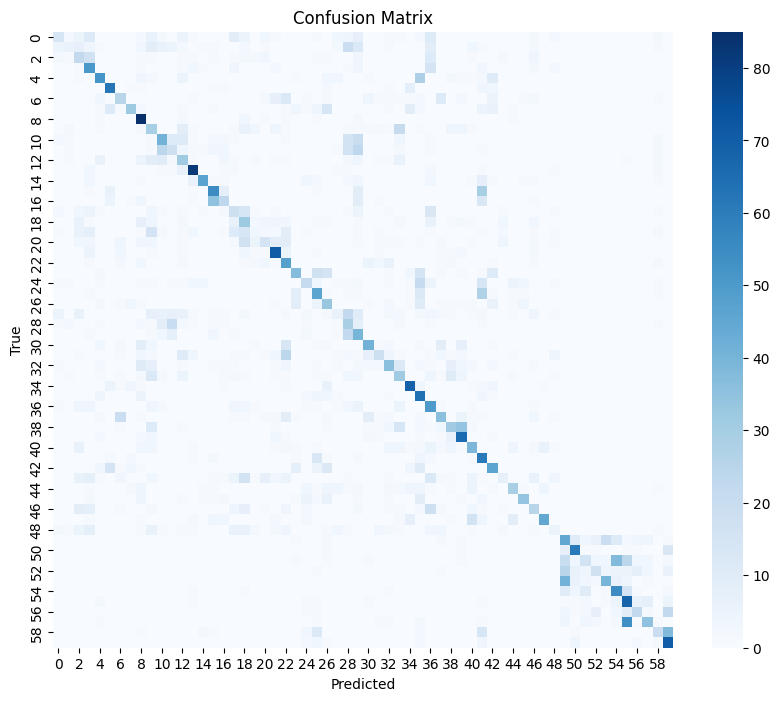

Оценка модели: 3DCNN
Оценка модели
Модель: 3dcnn
Лучшая точность при обучении: 60.41%
Метрики на тестовой выборке:
   Accuracy:  60.41%
   Precision: 61.87%
   Recall:    60.41%
   F1-score:  59.82%
   FPS:       773.21


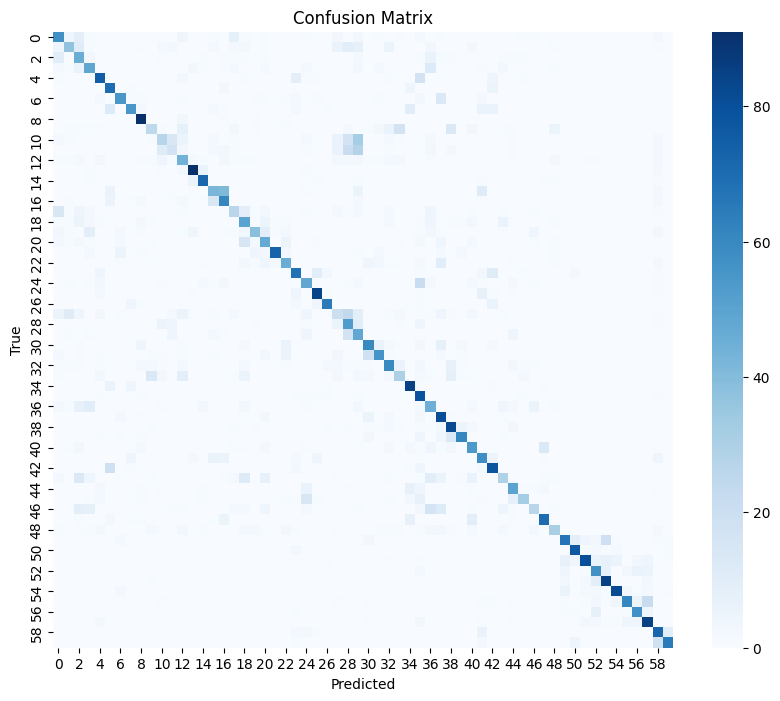

Оценка модели: STGCN
Оценка модели
Модель: stgcn
Лучшая точность при обучении: 15.14%
Метрики на тестовой выборке:
   Accuracy:  15.08%
   Precision: 17.79%
   Recall:    15.08%
   F1-score:  11.98%
   FPS:       75.92


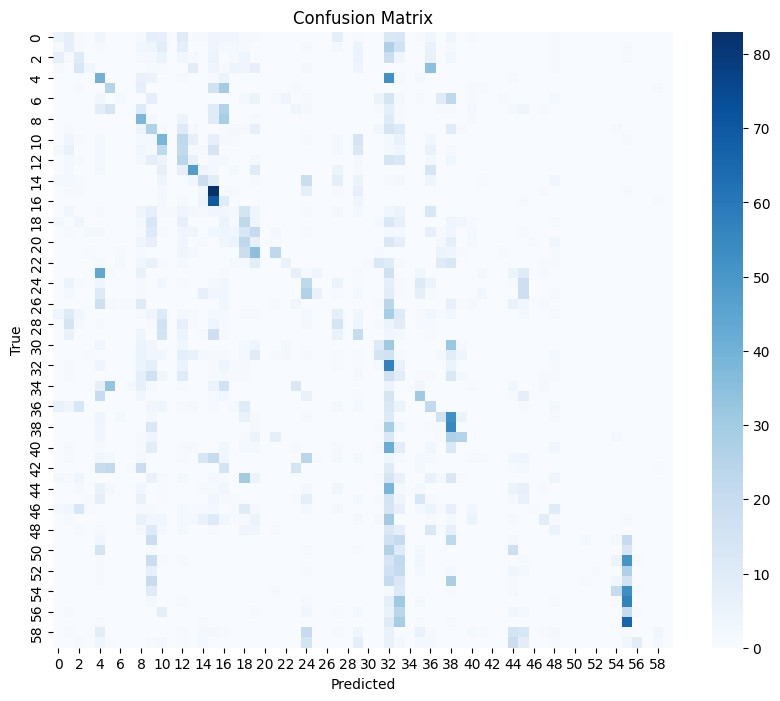

Оценка модели: TRANSFORMER
Оценка модели
Модель: transformer
Лучшая точность при обучении: 1.81%
Метрики на тестовой выборке:
   Accuracy:  1.81%
   Precision: 0.03%
   Recall:    1.81%
   F1-score:  0.06%
   FPS:       174.25


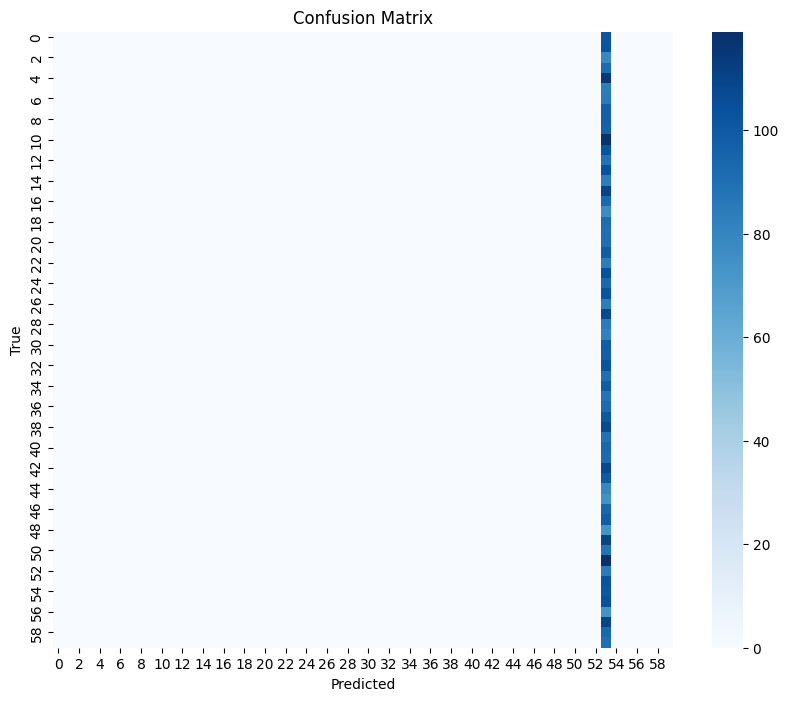

Сводное сравнение всех моделей
             Accuracy (%)  Precision (%)  Recall (%)  F1-score (%)      FPS
MLP                 39.64          41.61       39.64         38.10  2569.84
3DCNN               60.41          61.87       60.41         59.82   773.21
STGCN               15.08          17.79       15.08         11.98    75.92
TRANSFORMER          1.81           0.03        1.81          0.06   174.25
Лучшая модель по точности: 3DCNN
   Accuracy: 60.41%
Самая быстрая модель: MLP
   FPS: 2569.84
Сравнение сохранено: results/models_comparison.csv


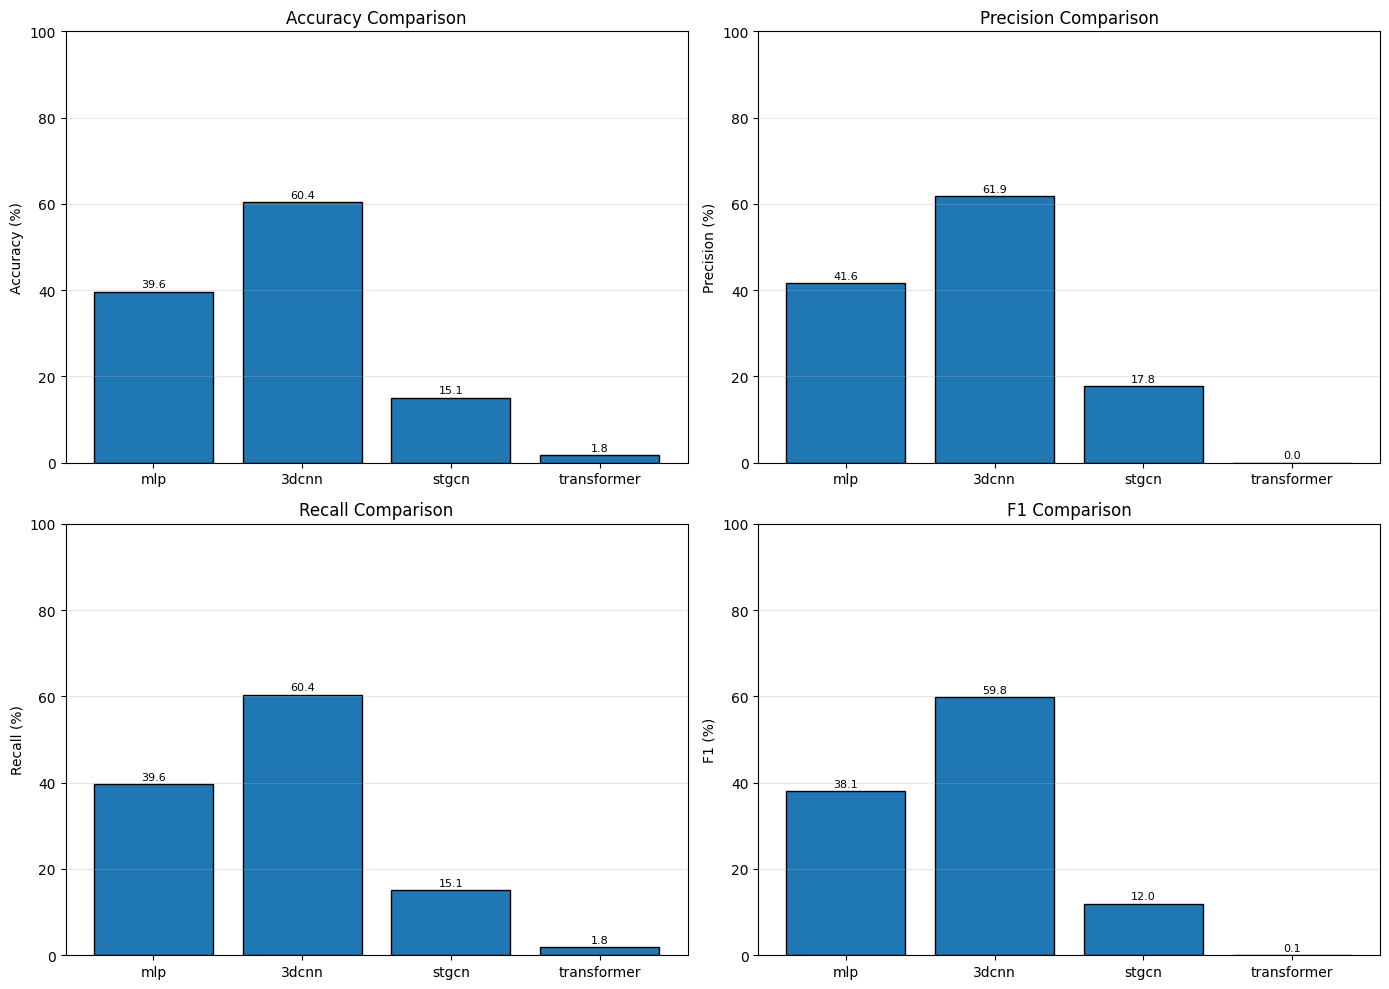


Путь к видео для демонстрации (оставьте пустым чтобы пропустить):  /home/kate/Documents/HakatonMarch2026/video.mp4



 ДЕМОСТРАЦИЯ...

ДЕМОНСТРАЦИЯ НА ВИДЕО
Модель: 3dcnn
MediaPipe версия: 0.10.32
Используется новый API MediaPipe
Ошибка инициализации MediaPipe: module 'mediapipe' has no attribute 'solutions'

Видео: /home/kate/Documents/HakatonMarch2026/video.mp4
Разрешение: 720x304
Всего кадров: 172581
Длительность: 7198.1 сек
Частота предсказаний: каждые 15 кадров
Выходное видео: results/demo_output.mp4

Обработка видео... (нажмите Q для остановки)


W0000 00:00:1774289123.310322   22471 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1774289123.334739   22472 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Кадр 99: action_58 (16.6%) | Людей: 1
Прогресс: 0.1% | Кадр: 100/172581 | ETA: 682с | Текущее действие: action_58
Кадр 114: action_58 (16.6%) | Людей: 1
Кадр 129: action_58 (16.6%) | Людей: 1
Кадр 144: action_58 (16.6%) | Людей: 1
Кадр 159: action_58 (16.6%) | Людей: 1
Кадр 174: action_58 (16.6%) | Людей: 1
Кадр 189: action_58 (16.6%) | Людей: 1
Прогресс: 0.1% | Кадр: 200/172581 | ETA: 698с | Текущее действие: action_58
Кадр 204: action_58 (16.6%) | Людей: 1
Кадр 219: action_58 (16.6%) | Людей: 1
Кадр 234: action_58 (16.6%) | Людей: 1
Кадр 249: action_58 (16.6%) | Людей: 1
Кадр 264: action_58 (16.6%) | Людей: 1
Кадр 279: action_58 (16.6%) | Людей: 1
Кадр 294: action_58 (16.6%) | Людей: 1
Прогресс: 0.2% | Кадр: 300/172581 | ETA: 696с | Текущее действие: action_58
Кадр 309: action_58 (16.6%) | Людей: 1
Кадр 324: action_58 (16.6%) | Людей: 1
Кадр 339: action_58 (16.6%) | Людей: 1
Кадр 354: action_58 (16.6%) | Людей: 1
Кадр 369: action_58 (16.6%) | Людей: 1
Кадр 384: action_58 (16.6%) | Лю

W0000 00:00:1774289292.856411   22571 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1774289292.879620   22577 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


   Детекция: 0.00 мс
   Инференс: 0.49 мс
   FPS: 2032.6
Бенчмарк модели: 3DCNN
MediaPipe версия: 0.10.32
Используется новый API MediaPipe
Ошибка инициализации MediaPipe: module 'mediapipe' has no attribute 'solutions'


W0000 00:00:1774289293.981781   22639 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1774289294.006278   22639 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


   Детекция: 0.00 мс
   Инференс: 1.30 мс
   FPS: 766.7
Бенчмарк модели: STGCN
MediaPipe версия: 0.10.32
Используется новый API MediaPipe
Ошибка инициализации MediaPipe: module 'mediapipe' has no attribute 'solutions'


W0000 00:00:1774289296.124951   22676 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1774289296.148967   22678 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [ ]:
# ============================================================================
# ЯЧЕЙКА ЗАПУСКА
# ============================================================================

def main():
    """
    Главная функция для запуска всех режимов работы системы
    """
    config = Config()
    
    print("\n" + "="*70)
    print("СИСТЕМА РАСПОЗНАВАНИЯ ДЕЙСТВИЙ ПО СКЕЛЕТНЫМ ДАННЫМ")
    print("Разработано для онлайн-кинотеатра «КИОН»")
    print("="*70)
    print(f"\nУстройство: {config.device}")
    if torch.cuda.is_available():
        print(f"GPU: {torch.cuda.get_device_name(0)}")
        print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    
    # Создание директорий
    os.makedirs(config.MODELS_DIR, exist_ok=True)
    os.makedirs(config.RESULTS_DIR, exist_ok=True)
    os.makedirs(config.LOGS_DIR, exist_ok=True)
    
    print("\n" + "="*70)
    print("ВЫБЕРИТЕ РЕЖИМ РАБОТЫ:")
    print("="*70)
    print("  1. Обучить одну модель")
    print("  2. Обучить все модели (MLP, 3DCNN, ST-GCN, Transformer)")
    print("  3. Сравнить все модели по метрикам")
    print("  4. Демонстрация на видео")
    print("  5. Бенчмарк производительности всех моделей")
    print("  6. Полный цикл (обучение → сравнение → демо → бенчмарк)")
    print("  7. Вывести информацию о моделях")
    print("  0. Быстрый старт (обучить 3DCNN + демо)")
    print("="*70)
    
    choice = input("\nВведите номер режима (0-7): ").strip()
    
    if choice == '0':
        # Быстрый старт для демонстрации
        print("\n БЫСТРЫЙ СТАРТ...")
        print("\n[1/3] Обучение модели 3DCNN...")
        train_model('3dcnn', num_epochs=30)
        
        print("\n[2/3] Оценка модели...")
        evaluate_model('models/3dcnn_best.pth')
        
        print("\n[3/3] Готово!")
        print(f"Модель сохранена: {config.MODELS_DIR}/3dcnn_best.pth")
        print(f"Результаты в: {config.RESULTS_DIR}/")
        
    elif choice == '1':
        print("\nДоступные модели:")
        for name in MODELS.keys():
            print(f"  - {name}: {MODELS[name]['description']}")
        model_name = input("\nВведите название модели: ").strip().lower()
        if model_name in MODELS:
            epochs = input("Количество эпох (по умолчанию 50): ").strip()
            epochs = int(epochs) if epochs else 50
            train_model(model_name, num_epochs=epochs)
        else:
            print(f" Модель '{model_name}' не найдена")
    
    elif choice == '2':
        print("\n ОБУЧЕНИЕ ВСЕХ МОДЕЛЕЙ...")
        for model_name in MODELS.keys():
            print(f"\n{'#'*70}")
            print(f"# ОБУЧЕНИЕ МОДЕЛИ: {model_name.upper()}")
            print(f"{'#'*70}")
            train_model(model_name, num_epochs=50)
        print("\n Обучение всех моделей завершено!")
        compare_all_models()
    
    elif choice == '3':
        compare_all_models()
    
    elif choice == '4':
        print("\nДоступные модели:")
        for name in MODELS.keys():
            model_path = os.path.join(config.MODELS_DIR, f'{name}_best.pth')
            status = "✅" if os.path.exists(model_path) else "❌"
            print(f"  {status} {name}: {MODELS[name]['description']}")
        
        model_name = input("\nВведите название модели для демонстрации: ").strip().lower()
        if model_name not in MODELS:
            print(f"Модель '{model_name}' не найдена")
            return
        
        model_path = os.path.join(config.MODELS_DIR, f'{model_name}_best.pth')
        if not os.path.exists(model_path):
            print(f"Модель не обучена. Сначала обучите её.")
            return
        
        video_path = input("Путь к видео: ").strip()
        if not video_path:
            print("Не указан путь к видео")
            return
        
        output_path = input("Путь для выходного видео (по умолчанию results/demo_output.mp4): ").strip()
        if not output_path:
            output_path = os.path.join(config.RESULTS_DIR, 'demo_output.mp4')
        
        demo_video(model_path, video_path, output_path)
    
    elif choice == '5':
        video_path = input("Путь к видео для бенчмарка: ").strip()
        if not video_path:
            print("Не указан путь к видео")
            return
        duration = input("Длительность теста в секундах (по умолчанию 60): ").strip()
        duration = int(duration) if duration else 60
        benchmark_all_models(video_path, duration)
    
    elif choice == '6':
        print("\n АПУСК ПОЛНОГО ЦИКЛА...")
        
        # Обучение всех моделей
        for model_name in MODELS.keys():
            model_path = os.path.join(config.MODELS_DIR, f'{model_name}_best.pth')
            if not os.path.exists(model_path):
                print(f"\n{'#'*70}")
                print(f"# ОБУЧЕНИЕ МОДЕЛИ: {model_name.upper()}")
                print(f"{'#'*70}")
                train_model(model_name, num_epochs=30)
            else:
                print(f"\n Модель {model_name} уже обучена")
        
        # Сравнение
        print("\n📊 СРАВНЕНИЕ МОДЕЛЕЙ...")
        compare_all_models()
        
        # Демонстрация
        video_path = input("\nПуть к видео для демонстрации (оставьте пустым чтобы пропустить): ").strip()
        if video_path:
            print("\n ДЕМОСТРАЦИЯ...")
            best_model_path = os.path.join(config.MODELS_DIR, '3dcnn_best.pth')
            demo_video(best_model_path, video_path)
            
            print("\n⚡ БЕНЧМАРК...")
            benchmark_all_models(video_path)
    
    elif choice == '7':
        print("\n" + "="*70)
        print("ИНФОРМАЦИЯ О МОДЕЛЯХ")
        print("="*70)
        for name, info in MODELS.items():
            print(f"\n{name.upper()}")
            print(f"   Описание: {info['description']}")
            print(f"   Особенности: {', '.join(info['features'])}")
            print(f"   Параметры: {info['params']}")
            model_path = os.path.join(config.MODELS_DIR, f'{name}_best.pth')
            if os.path.exists(model_path):
                checkpoint = torch.load(model_path, map_location='cpu', weights_only=False)
                acc = checkpoint.get('accuracy', 0)
                print(f"   Статус:  Обучена (Accuracy: {acc:.2f}%)")
            else:
                print(f"   Статус:  Не обучена")
    
    else:
        print("Неверный выбор")
    
    print("\n" + "="*70)
    print("РАБОТА ЗАВЕРШЕНА!")
    print("="*70)

# Запуск главной функции
if __name__ == "__main__":
    main()

# Известные ограничения

## 1. Класс "Курение"
Отсутствует в NTU RGB+D 60. Требуется дополнительный датасет.

## 2. Класс "Треугольник"
Отсутствует в NTU RGB+D 60. Реализован только "Круг".

## 3. Мультидетекция
MediaPipe Pose детектирует 1 человека. Для групповых действий 
рекомендуется YOLOv8-Pose в продакшене.